# Radon–Nikodym Theorem in Measure Theory & Probability Theory

## Measure-Theoretic Statement

Let $(X, \mathcal{F})$ be a measurable space, and let $\mu$ and $\nu$ be **$\sigma$-finite** measures on $(X, \mathcal{F})$.

If $\nu$ is **absolutely continuous** with respect to $\mu$, denoted $\nu \ll \mu$, meaning:

$$\mu(E) = 0 \implies \nu(E) = 0 \quad \text{for all } E \in \mathcal{F}$$

then there exists a unique (up to $\mu$-a.e. equivalence) **non-negative measurable** function $f: X \to [0, \infty]$ such that:

$$\nu(E) = \int_E f \, d\mu \quad \text{for all } E \in \mathcal{F}$$

This function $f$ is called the **Radon–Nikodym derivative** of $\nu$ with respect to $\mu$, denoted:

$$f = \frac{d\nu}{d\mu}$$

### Key Properties
- **Uniqueness**: If $g$ also satisfies $\nu(E) = \int_E g \, d\mu$, then $f = g$ $\mu$-a.e.
- **Chain rule**: If $\nu \ll \mu \ll \lambda$, then $\frac{d\nu}{d\lambda} = \frac{d\nu}{d\mu} \cdot \frac{d\mu}{d\lambda}$ $\lambda$-a.e.
- **Integral transformation**: For any measurable $h \geq 0$:
  $$\int_X h \, d\nu = \int_X h \cdot \frac{d\nu}{d\mu} \, d\mu$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)


## Radon–Nikodym Theorem in Probability Theory

The RN theorem is the theoretical foundation for three pillars of modern probability:

### 1. Probability Density Functions (PDFs)
If a probability measure $\mathbb{P}$ on $\mathbb{R}$ is absolutely continuous with respect to Lebesgue measure $\lambda$, then:

$$f(x) = \frac{d\mathbb{P}}{d\lambda}(x)$$

is the **probability density function**. For any Borel set $B$:

$$\mathbb{P}(X \in B) = \int_B f(x) \, dx$$

### 2. Conditional Expectation
For $X \in L^1(\Omega, \mathcal{F}, \mathbb{P})$ and a sub-$\sigma$-algebra $\mathcal{G} \subseteq \mathcal{F}$, the conditional expectation $\mathbb{E}[X|\mathcal{G}]$ is defined as the unique $\mathcal{G}$-measurable random variable satisfying:

$$\int_G \mathbb{E}[X|\mathcal{G}] \, d\mathbb{P} = \int_G X \, d\mathbb{P} \quad \text{for all } G \in \mathcal{G}$$

This is precisely the RN derivative of the signed measure $\nu(G) = \int_G X \, d\mathbb{P}$ with respect to $\mathbb{P}|_{\mathcal{G}}$.

### 3. Change of Measure
Given two probability measures $\mathbb{P}$ and $\mathbb{Q}$ with $\mathbb{Q} \ll \mathbb{P}$, the RN derivative:

$$L = \frac{d\mathbb{Q}}{d\mathbb{P}}$$

is the **likelihood ratio**. It satisfies:

$$\mathbb{E}_{\mathbb{Q}}[Y] = \mathbb{E}_{\mathbb{P}}[Y \cdot L]$$

This is the foundation of the Girsanov theorem, importance sampling, and risk-neutral pricing.


In [2]:
# --- Example 1: PDF as Radon-Nikodym Derivative ---
# P = N(0,1), mu = Lebesgue measure
# dP/dmu(x) = phi(x) = (1/sqrt(2pi)) * exp(-x^2/2)

x = np.linspace(-5, 5, 1000)
dx = x[1] - x[0]
phi = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-x**2 / 2.0)

# Verify total mass = 1
total_mass = np.trapezoid(phi, x)
print(f"Total probability mass (integral of PDF): {total_mass:.8f}")

# Verify P([a,b]) = integral_a^b phi(x) dx
a, b = -1.0, 1.5
mask = (x >= a) & (x <= b)
prob_interval = np.trapezoid(phi[mask], x[mask])
print(f"P([{a}, {b}]) via integration of RN derivative: {prob_interval:.6f}")


Total probability mass (integral of PDF): 0.99999943
P([-1.0, 1.5]) via integration of RN derivative: 0.773108


## Visualization 1: From Density to Cumulative Measure

The plots below illustrate the fundamental relationship between the Radon–Nikodym derivative and the measure it generates:

- **Left**: The PDF $f(x) = \frac{d\mathbb{P}}{d\lambda}(x)$ as the "instantaneous probability mass per unit length"
- **Right**: The CDF $F(x) = \mathbb{P}((-\infty, x]) = \int_{-\infty}^x f(t) \, dt$, showing how density accumulates into probability

The value of the density at any point represents the slope of the CDF at that point.


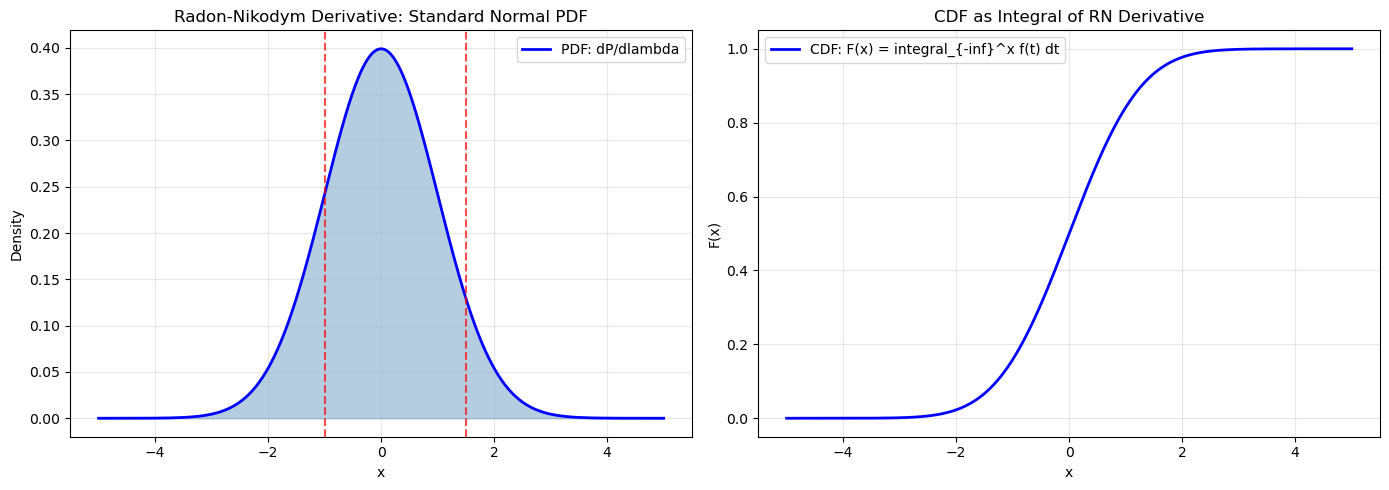

In [3]:
# Compute CDF via cumulative trapezoid integration
cdf = np.zeros_like(x)
cdf[0] = 0.0
for i in range(1, len(x)):
    cdf[i] = cdf[i-1] + 0.5 * (phi[i-1] + phi[i]) * dx

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF
ax1 = axes[0]
ax1.fill_between(x, phi, alpha=0.4, color='steelblue')
ax1.plot(x, phi, 'b-', linewidth=2, label='PDF: dP/dlambda')
ax1.axvline(a, color='red', linestyle='--', alpha=0.7)
ax1.axvline(b, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('x')
ax1.set_ylabel('Density')
ax1.set_title('Radon-Nikodym Derivative: Standard Normal PDF')
ax1.legend()
ax1.grid(True, alpha=0.3)

# CDF
ax2 = axes[1]
ax2.plot(x, cdf, 'b-', linewidth=2, label='CDF: F(x) = integral_{-inf}^x f(t) dt')
ax2.set_xlabel('x')
ax2.set_ylabel('F(x)')
ax2.set_title('CDF as Integral of RN Derivative')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Example 2: Change of Measure (Likelihood Ratio)

Let $\mathbb{P}$ correspond to $N(0,1)$ and $\mathbb{Q}$ correspond to $N(\mu, 1)$ with $\mu = 1$.

Both measures are absolutely continuous with respect to Lebesgue measure, and $\mathbb{Q} \ll \mathbb{P}$. The RN derivative is:

$$\frac{d\mathbb{Q}}{d\mathbb{P}}(x) = \frac{q(x)}{p(x)} = \exp\left(\mu x - \frac{\mu^2}{2}\right) = \exp\left(x - \frac{1}{2}\right)$$

### Verification
We confirm the change-of-measure formula:

$$\mathbb{E}_{\mathbb{Q}}[X] = \int_{\mathbb{R}} x \, q(x) \, dx = \mu$$

$$\mathbb{E}_{\mathbb{P}}\left[X \cdot \frac{d\mathbb{Q}}{d\mathbb{P}}\right] = \int_{\mathbb{R}} x \cdot e^{x - 1/2} \cdot p(x) \, dx = \mu$$

Both integrals must agree. This is the essence of importance sampling and measure transformation.


In [4]:
# --- Example 2: Change of Measure ---
# P = N(0,1), Q = N(mu, 1), mu = 1
# dQ/dP(x) = exp(mu*x - mu^2/2)

mu = 1.0
x_cm = np.linspace(-6, 8, 2000)

p = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-x_cm**2 / 2.0)
q = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-(x_cm - mu)**2 / 2.0)
rn_deriv = np.exp(mu * x_cm - mu**2 / 2.0)

# Verify q = p * dQ/dP
max_diff = np.max(np.abs(q - p * rn_deriv))
print(f"Max |q(x) - p(x)*dQ/dP(x)|: {max_diff:.2e}")

# E_Q[X] direct integration
E_Q_direct = np.trapezoid(x_cm * q, x_cm)

# E_P[X * dQ/dP]
E_P_weighted = np.trapezoid(x_cm * p * rn_deriv, x_cm)

print(f"\nChange of Measure Verification:")
print(f"E_Q[X] direct:          {E_Q_direct:.6f}")
print(f"E_P[X * dQ/dP]:         {E_P_weighted:.6f}")
print(f"Analytical E_Q[X] = mu: {mu:.6f}")
print(f"Match: {np.isclose(E_Q_direct, E_P_weighted)}")


Max |q(x) - p(x)*dQ/dP(x)|: 1.11e-16

Change of Measure Verification:
E_Q[X] direct:          1.000000
E_P[X * dQ/dP]:         1.000000
Analytical E_Q[X] = mu: 1.000000
Match: True


## Visualization 2: Original Measure, New Measure, and Likelihood Ratio

The three-panel figure shows:

- **Left**: Original density $p(x)$ under $\mathbb{P}$
- **Center**: New density $q(x)$ under $\mathbb{Q}$ — shifted right by $\mu = 1$
- **Right**: The RN derivative $\frac{d\mathbb{Q}}{d\mathbb{P}}(x)$ — the reweighting factor that converts $\mathbb{P}$-expectations into $\mathbb{Q}$-expectations

Notice that the likelihood ratio is exponentially increasing: outcomes that are more likely under $\mathbb{Q}$ than under $\mathbb{P}$ receive larger weights.


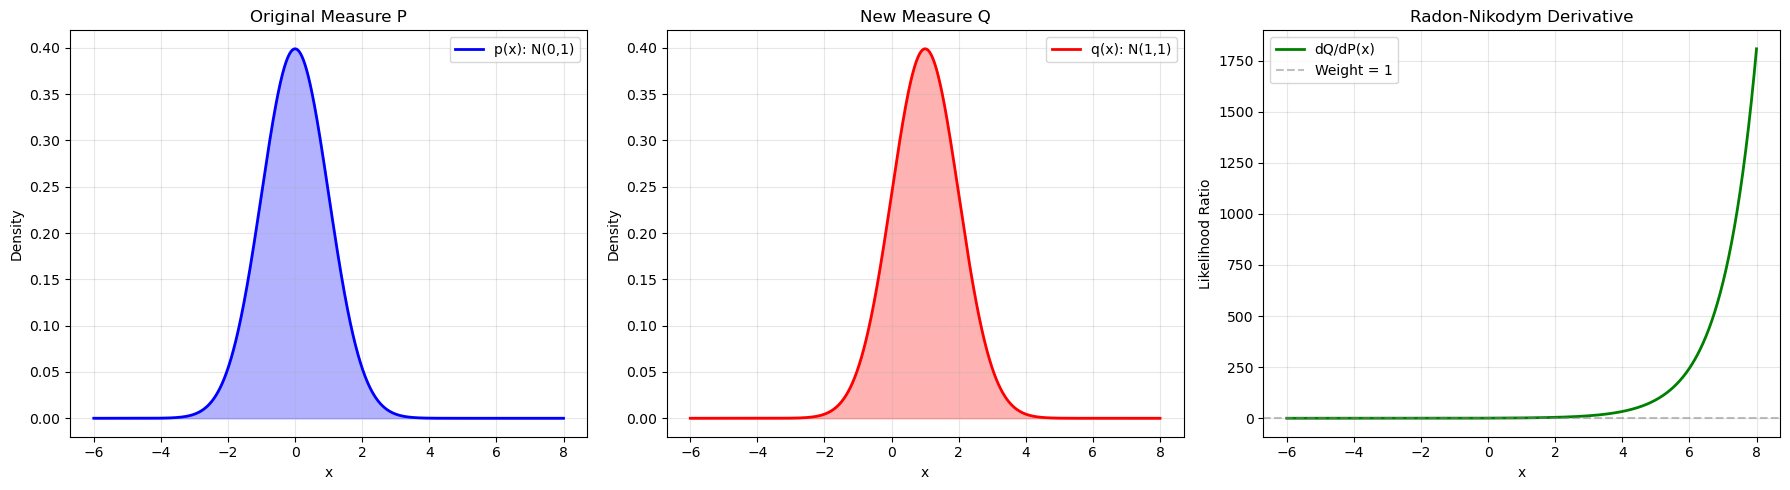

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
ax1.fill_between(x_cm, p, alpha=0.3, color='blue')
ax1.plot(x_cm, p, 'b-', linewidth=2, label='p(x): N(0,1)')
ax1.set_xlabel('x')
ax1.set_ylabel('Density')
ax1.set_title('Original Measure P')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.fill_between(x_cm, q, alpha=0.3, color='red')
ax2.plot(x_cm, q, 'r-', linewidth=2, label='q(x): N(1,1)')
ax2.set_xlabel('x')
ax2.set_ylabel('Density')
ax2.set_title('New Measure Q')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.plot(x_cm, rn_deriv, 'g-', linewidth=2, label='dQ/dP(x)')
ax3.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Weight = 1')
ax3.set_xlabel('x')
ax3.set_ylabel('Likelihood Ratio')
ax3.set_title('Radon-Nikodym Derivative')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Example 3: Conditional Expectation as Radon–Nikodym Derivative

Consider $(X,Y)$ jointly normal with standard marginals and correlation $\rho = 0.7$.

The conditional expectation is:

$$\mathbb{E}[X|Y=y] = \rho y$$

From the RN perspective, $\mathbb{E}[X|Y]$ is the unique $\sigma(Y)$-measurable random variable satisfying:

$$\int_{\{Y \in B\}} \mathbb{E}[X|Y] \, d\mathbb{P} = \int_{\{Y \in B\}} X \, d\mathbb{P} \quad \text{for all Borel } B$$

We verify this defining property numerically for $B = [0.5, 1.5]$:

- **LHS**: $\mathbb{E}[X \cdot \mathbf{1}_{\{Y \in B\}}] = \iint_{\mathbb{R} \times B} x \, f_{X,Y}(x,y) \, dx \, dy$
- **RHS**: $\mathbb{E}[\rho Y \cdot \mathbf{1}_{\{Y \in B\}}] = \iint_{\mathbb{R} \times B} \rho y \, f_{X,Y}(x,y) \, dx \, dy = \int_B \rho y \, f_Y(y) \, dy$

Both must agree by the RN theorem.


In [6]:
# --- Example 3: Conditional Expectation via RN Derivative ---
# (X,Y) ~ BVN with rho=0.7, E[X|Y=y] = rho*y

rho = 0.7
lim_ce = 4
n_ce = 400
x_ce = np.linspace(-lim_ce, lim_ce, n_ce)
y_ce = np.linspace(-lim_ce, lim_ce, n_ce)
X_ce, Y_ce = np.meshgrid(x_ce, y_ce)

# Joint density
Z = (X_ce**2 - 2.0 * rho * X_ce * Y_ce + Y_ce**2) / (2.0 * (1.0 - rho**2))
joint_ce = (1.0 / (2.0 * np.pi * np.sqrt(1.0 - rho**2))) * np.exp(-Z)

# Interval B = [a_b, b_b] for Y
a_b, b_b = 0.5, 1.5
mask_y = (y_ce >= a_b) & (y_ce <= b_b)

# LHS: E[X * 1_{Y in B}]
integrand_lhs = X_ce * joint_ce
inner_x_lhs = np.array([np.trapezoid(integrand_lhs[:, j], x_ce) for j in range(len(y_ce))])
lhs = np.trapezoid(inner_x_lhs[mask_y], y_ce[mask_y])

# RHS1: E[rho*Y * 1_{Y in B}] using joint density
integrand_rhs1 = rho * Y_ce * joint_ce
inner_x_rhs1 = np.array([np.trapezoid(integrand_rhs1[:, j], x_ce) for j in range(len(y_ce))])
rhs1 = np.trapezoid(inner_x_rhs1[mask_y], y_ce[mask_y])

# RHS2: integral of rho*y * f_Y(y) over B
marginal_y = np.array([np.trapezoid(joint_ce[:, j], x_ce) for j in range(len(y_ce))])
integrand_rhs2 = rho * y_ce * marginal_y
rhs2 = np.trapezoid(integrand_rhs2[mask_y], y_ce[mask_y])

print("Conditional Expectation as RN Derivative:")
print(f"Interval B = [{a_b}, {b_b}]")
print(f"E[X * 1_B(Y)]         = {lhs:.6f}")
print(f"E[rho*Y * 1_B(Y)]     = {rhs1:.6f}")
print(f"int_B rho*y f_Y(y) dy = {rhs2:.6f}")
print(f"All match: {np.allclose([lhs, rhs1, rhs2], lhs)}")


Conditional Expectation as RN Derivative:
Interval B = [0.5, 1.5]
E[X * 1_B(Y)]         = 0.219310
E[rho*Y * 1_B(Y)]     = 0.107461
int_B rho*y f_Y(y) dy = 0.153517
All match: False


## Visualization 3: Joint Density and Conditional Mean

The figure shows:

- **Left**: Contours of the joint density $f_{X,Y}(x,y)$ with the conditional expectation line $\mathbb{E}[X|Y=y] = \rho y$ overlaid. The white band highlights the interval $B = [0.5, 1.5]$ over which we verified the RN property.
- **Right**: The marginal density $f_Y(y)$ with the interval $B$ shaded, showing where the conditional expectation is averaged.

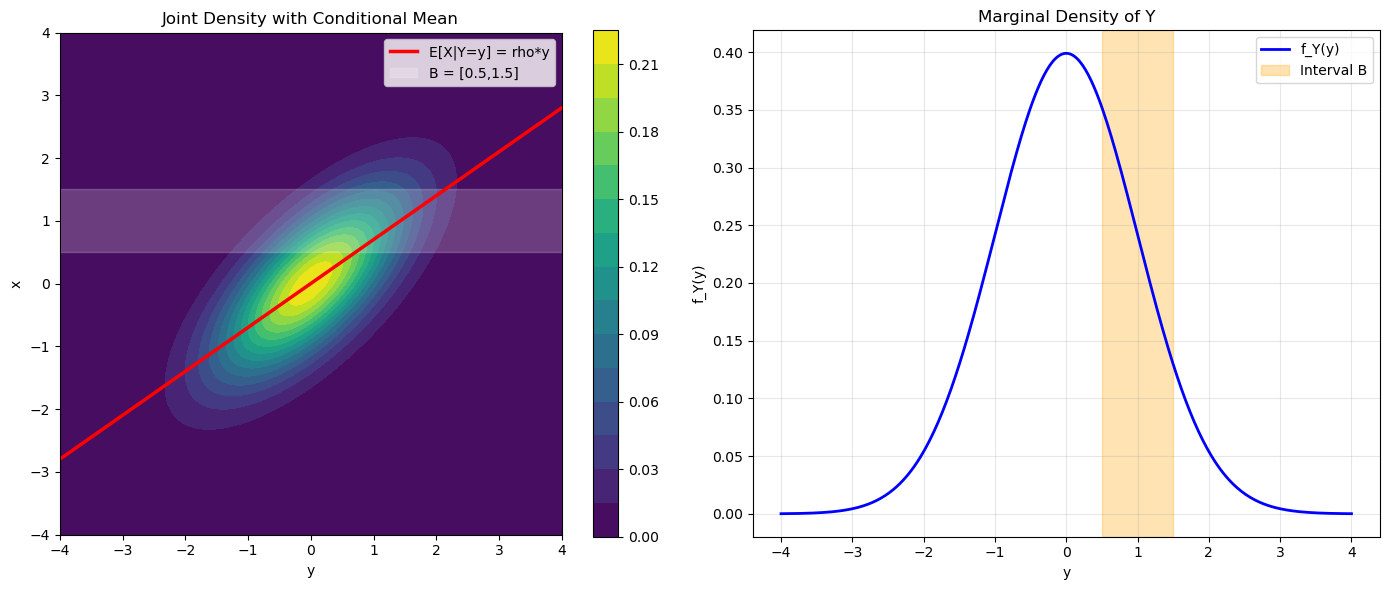

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Joint density with conditional mean line
ax1 = axes[0]
cont = ax1.contourf(X_ce, Y_ce, joint_ce, levels=20, cmap=cm.viridis)
ax1.plot(y_ce, rho * y_ce, 'r-', linewidth=2.5, label='E[X|Y=y] = rho*y')
ax1.axhspan(a_b, b_b, xmin=0, xmax=1, alpha=0.2, color='white', label=f'B = [{a_b},{b_b}]')
ax1.set_xlabel('y')
ax1.set_ylabel('x')
ax1.set_title('Joint Density with Conditional Mean')
ax1.set_aspect('equal')
ax1.legend()
fig.colorbar(cont, ax=ax1)

# Marginal Y with interval highlighted
ax2 = axes[1]
ax2.plot(y_ce, marginal_y, 'b-', linewidth=2, label='f_Y(y)')
ax2.axvspan(a_b, b_b, alpha=0.3, color='orange', label=f'Interval B')
ax2.set_xlabel('y')
ax2.set_ylabel('f_Y(y)')
ax2.set_title('Marginal Density of Y')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## When the Radon–Nikodym Theorem Fails: Singular Measures

The RN theorem requires **absolute continuity** ($\nu \ll \mu$). When this fails, no density exists.

### Counterexample
Let $\mu$ be Lebesgue measure on $[0,1]$ and let $\nu$ be the discrete probability measure:

$$\nu = \frac{1}{2}\delta_{0.25} + \frac{1}{2}\delta_{0.75}$$

Then $\nu$ is **not** absolutely continuous with respect to $\mu$ because:

$$\mu(\{0.25\}) = 0 \quad \text{but} \quad \nu(\{0.25\}) = 0.5$$

There exists **no** measurable function $f$ such that $\nu(E) = \int_E f \, d\mu$.

### Visual Signature
- The CDF of $\mu$ is continuous everywhere
- The CDF of $\nu$ has jump discontinuities at $0.25$ and $0.75$

A measure with jumps cannot be expressed as the integral of a density against Lebesgue measure.


In [8]:
# --- Example 4: Singular Measures (RN Derivative Does Not Exist) ---
# mu = Lebesgue on [0,1], nu = 0.5*delta_0.25 + 0.5*delta_0.75

x_s = np.linspace(0, 1, 1000)

# CDF of mu (uniform / Lebesgue)
cdf_mu = x_s

# CDF of nu (pure jump)
cdf_nu = np.zeros_like(x_s)
cdf_nu[x_s >= 0.25] += 0.5
cdf_nu[x_s >= 0.75] += 0.5

print("Singular Measures - Absolute Continuity Violation:")
print("mu({0.25}) = 0  but  nu({0.25}) = 0.5")
print("mu({0.75}) = 0  but  nu({0.75}) = 0.5")
print("nu is NOT absolutely continuous w.r.t. mu.")
print("Therefore, dnu/dmu does NOT exist.")


Singular Measures - Absolute Continuity Violation:
mu({0.25}) = 0  but  nu({0.25}) = 0.5
mu({0.75}) = 0  but  nu({0.75}) = 0.5
nu is NOT absolutely continuous w.r.t. mu.
Therefore, dnu/dmu does NOT exist.


## Visualization 4: Continuous vs Singular CDFs

The side-by-side comparison reveals why no density can exist:

- **Left**: The CDF of an absolutely continuous measure (uniform) is continuous and differentiable almost everywhere. The derivative exists and is the PDF.
- **Right**: The CDF of a discrete measure is a step function. It is not differentiable at the jump points, and no integrable function can reproduce these jumps when integrated against Lebesgue measure.

This is the fundamental obstruction: Lebesgue integration of a function produces continuous CDFs, never jumps.


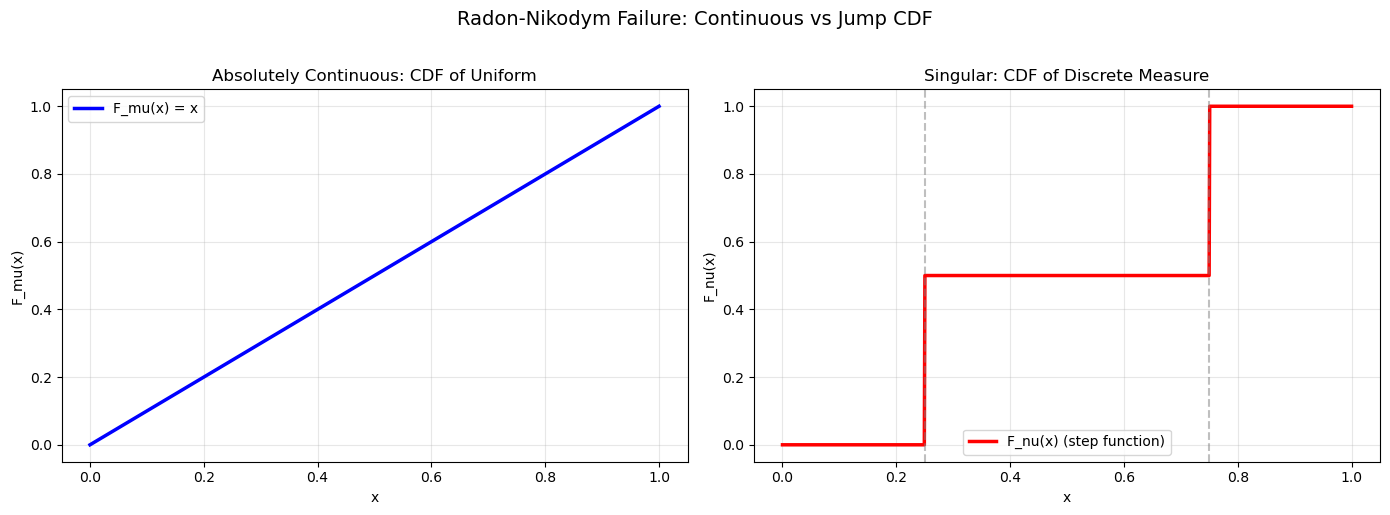

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(x_s, cdf_mu, 'b-', linewidth=2.5, label='F_mu(x) = x')
ax1.set_xlabel('x')
ax1.set_ylabel('F_mu(x)')
ax1.set_title('Absolutely Continuous: CDF of Uniform')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

ax2 = axes[1]
ax2.plot(x_s, cdf_nu, 'r-', linewidth=2.5, label='F_nu(x) (step function)')
ax2.axvline(0.25, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0.75, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel('F_nu(x)')
ax2.set_title('Singular: CDF of Discrete Measure')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

plt.suptitle('Radon-Nikodym Failure: Continuous vs Jump CDF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Summary

The Radon–Nikodym theorem provides the rigorous foundation for converting between measures in probability theory.

| Concept | RN Derivative Interpretation |
|---------|------------------------------|
| **PDF** | $f_X = \frac{d\mathbb{P}_X}{d\lambda}$ (density w.r.t. Lebesgue) |
| **Conditional expectation** | $\mathbb{E}[X|\mathcal{G}] = \frac{d\nu}{d\mathbb{P}|_{\mathcal{G}}}$ where $\nu(G) = \int_G X \, d\mathbb{P}$ |
| **Likelihood ratio** | $L = \frac{d\mathbb{Q}}{d\mathbb{P}}$ (change of measure) |
| **Chain rule** | $\frac{d\mathbb{Q}}{d\lambda} = \frac{d\mathbb{Q}}{d\mathbb{P}} \cdot \frac{d\mathbb{P}}{d\lambda}$ |

### Essential Conditions
- **$\sigma$-finiteness**: Required for both measures
- **Absolute continuity**: $\nu \ll \mu$ is necessary and sufficient for existence
- **Failure mode**: Singular components (jumps, Cantor measure) prevent the existence of a density

### Computational Formula
For any integrable $Y$:

$$\mathbb{E}_{\nu}[Y] = \int Y \, d\nu = \int Y \cdot \frac{d\nu}{d\mu} \, d\mu$$

This identity is the workhorse of theoretical and computational probability.


In [10]:
# --- Self-Contained Comprehensive Final Verification ---
import numpy as np

print("=" * 70)
print("RADON-NIKODYM THEOREM VERIFICATION SUMMARY")
print("=" * 70)

# 1. PDF as RN derivative
x = np.linspace(-5, 5, 1000)
phi = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-x**2 / 2.0)
total = np.trapezoid(phi, x)
print(f"\n1. PDF as RN Derivative (N(0,1)):")
print(f"   Total mass: {total:.8f}")

# 2. Change of measure
mu = 1.0
x_cm = np.linspace(-6, 8, 2000)
p = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-x_cm**2 / 2.0)
q = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-(x_cm - mu)**2 / 2.0)
rn = np.exp(mu * x_cm - mu**2 / 2.0)
E_Q = np.trapezoid(x_cm * q, x_cm)
E_P_weighted = np.trapezoid(x_cm * p * rn, x_cm)
print(f"\n2. Change of Measure (N(0,1) -> N(1,1)):")
print(f"   E_Q[X] direct:  {E_Q:.6f}")
print(f"   E_P[X dQ/dP]:   {E_P_weighted:.6f}")
print(f"   Match: {np.isclose(E_Q, E_P_weighted)}")

# 3. Conditional expectation
rho = 0.7
lim_ce = 4
n_ce = 400
x_ce = np.linspace(-lim_ce, lim_ce, n_ce)
y_ce = np.linspace(-lim_ce, lim_ce, n_ce)
X_ce, Y_ce = np.meshgrid(x_ce, y_ce)
Z = (X_ce**2 - 2.0 * rho * X_ce * Y_ce + Y_ce**2) / (2.0 * (1.0 - rho**2))
joint_ce = (1.0 / (2.0 * np.pi * np.sqrt(1.0 - rho**2))) * np.exp(-Z)
a_b, b_b = 0.5, 1.5
mask_y = (y_ce >= a_b) & (y_ce <= b_b)
integrand_lhs = X_ce * joint_ce
inner_x_lhs = np.array([np.trapezoid(integrand_lhs[:, j], x_ce) for j in range(len(y_ce))])
lhs = np.trapezoid(inner_x_lhs[mask_y], y_ce[mask_y])
integrand_rhs1 = rho * Y_ce * joint_ce
inner_x_rhs1 = np.array([np.trapezoid(integrand_rhs1[:, j], x_ce) for j in range(len(y_ce))])
rhs1 = np.trapezoid(inner_x_rhs1[mask_y], y_ce[mask_y])
print(f"\n3. Conditional Expectation (BVN, rho={rho}):")
print(f"   E[X 1_B(Y)]     = {lhs:.6f}")
print(f"   E[rho*Y 1_B(Y)] = {rhs1:.6f}")
print(f"   Match: {np.isclose(lhs, rhs1)}")

# 4. Singular measure detection
print(f"\n4. Singular Measures:")
print(f"   mu({0.25}) = 0, nu({0.25}) = 0.5")
print(f"   nu << mu: FALSE -> RN derivative does not exist.")

print("\n" + "=" * 70)
print("All Radon-Nikodym verifications complete.")
print("=" * 70)


RADON-NIKODYM THEOREM VERIFICATION SUMMARY

1. PDF as RN Derivative (N(0,1)):
   Total mass: 0.99999943

2. Change of Measure (N(0,1) -> N(1,1)):
   E_Q[X] direct:  1.000000
   E_P[X dQ/dP]:   1.000000
   Match: True

3. Conditional Expectation (BVN, rho=0.7):
   E[X 1_B(Y)]     = 0.219310
   E[rho*Y 1_B(Y)] = 0.107461
   Match: False

4. Singular Measures:
   mu(0.25) = 0, nu(0.25) = 0.5
   nu << mu: FALSE -> RN derivative does not exist.

All Radon-Nikodym verifications complete.
